In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    learning_curve,
)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [149]:
DATA_PATH = "../datasets/Ames_Housing_Data.csv"
TARGET = "SalePrice"
RANDOM_STATE = 13
TEST_SIZE = 0.2

NUMERIC_FEATURES = [
    "MS SubClass",
    "Lot Frontage",
    "Lot Area",
    "Overall Qual",
    "Overall Cond",
    "Years since Built",
    "Years since Remod/Add",
    "Mas Vnr Area",
    "BsmtFin SF 1",
    "BsmtFin SF 2",
    "Bsmt Unf SF",
    "Total Bsmt SF",
    "1st Flr SF",
    "2nd Flr SF",
    "Low Qual Fin SF",
    "Gr Liv Area",
    "Bsmt Full Bath",
    "Bsmt Half Bath",
    "Full Bath",
    "Half Bath",
    "Bedroom AbvGr",
    "Kitchen AbvGr",
    "TotRms AbvGrd",
    "Fireplaces",
    "Years since Garage Blt",
    "Garage Cars",
    "Garage Area",
    "Wood Deck SF",
    "Open Porch SF",
    "Enclosed Porch",
    "3Ssn Porch",
    "Screen Porch",
    "Pool Area",
    "Misc Val",
    "Mo Sold",
]
CATEGORICAL_FEATURES = [
    "MS Zoning",
    "Street",
    "Alley",
    "Lot Shape",
    "Land Contour",
    "Utilities",
    "Lot Config",
    "Land Slope",
    "Neighborhood",
    "Condition 1",
    "Condition 2",
    "Bldg Type",
    "House Style",
    "Roof Style",
    "Roof Matl",
    "Exterior 1st",
    "Exterior 2nd",
    "Mas Vnr Type",
    "Exter Qual",
    "Exter Cond",
    "Foundation",
    "Bsmt Qual",
    "Bsmt Cond",
    "Bsmt Exposure",
    "BsmtFin Type 1",
    "BsmtFin Type 2",
    "Heating",
    "Heating QC",
    "Central Air",
    "Electrical",
    "Kitchen Qual",
    "Functional",
    "Fireplace Qu",
    "Garage Type",
    "Garage Finish",
    "Garage Qual",
    "Garage Cond",
    "Paved Drive",
    "Pool QC",
    "Fence",
    "Misc Feature",
    "Sale Type",
    "Sale Condition",
]

In [243]:
data = pd.read_csv(DATA_PATH)

pd.set_option("display.max_columns", None)
print(data.shape)
display(data.head())
data.info()
missing_counts = data.isna().sum()
missing_counts[missing_counts > 0]

(2930, 81)


,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2930 non-null   int64  
 1   MS SubClass      2930 non-null   int64  
 2   MS Zoning        2930 non-null   str    
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Street           2930 non-null   str    
 6   Alley            198 non-null    str    
 7   Lot Shape        2930 non-null   str    
 8   Land Contour     2930 non-null   str    
 9   Utilities        2930 non-null   str    
 10  Lot Config       2930 non-null   str    
 11  Land Slope       2930 non-null   str    
 12  Neighborhood     2930 non-null   str    
 13  Condition 1      2930 non-null   str    
 14  Condition 2      2930 non-null   str    
 15  Bldg Type        2930 non-null   str    
 16  House Style      2930 non-null   str    
 17  Overall Qual     2930 non

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

In [294]:
data["Years since Built"] = data["Yr Sold"] - data["Year Built"]
data["Years since Remod/Add"] = data["Yr Sold"] - data["Year Remod/Add"]
data["Years since Garage Blt"] = data["Yr Sold"] - data["Garage Yr Blt"]

In [295]:
X = data.drop(
    columns=[TARGET, "Year Built", "Year Remod/Add", "Garage Yr Blt", "Yr Sold", "PID"]
)
y = data[TARGET]

In [296]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

In [ ]:
numeric_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", numeric_pipeline, NUMERIC_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    verbose_feature_names_out=False,
)

In [298]:
model = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("regressor", DecisionTreeRegressor(random_state=RANDOM_STATE)),
    ]
)

In [ ]:
param_grid = {
    "regressor__max_depth": [4, 6, 8, None],
    "regressor__min_samples_split": [2, 10, 20],
    "regressor__min_samples_leaf": [1, 5, 10],
    "regressor__criterion": ["squared_error", "absolute_error"],
    "regressor__ccp_alpha": [0.0, 0.0001],
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1,
    refit=True,
)

In [300]:
grid.fit(X_train, y_train)

model = grid.best_estimator_
fitted_preprocessor = model.named_steps["preprocessor"]
fitted_tree = model.named_steps["regressor"]

print("Best params:", grid.best_params_)
print("Best r2 score:", grid.best_score_)

Best params: {'regressor__ccp_alpha': 0.0, 'regressor__criterion': 'friedman_mse', 'regressor__max_depth': None, 'regressor__min_samples_leaf': 10, 'regressor__min_samples_split': 2}
Best r2 score: 0.8146521635023859


In [301]:
y_pred = model.predict(X_test)

In [302]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
residuals = y_test - y_pred

print(f"{r2=}")
print(f"{mse=}")
print(f"{mae=}")

r2=0.8241608018793343
mse=1180179485.6499994
mae=20498.028770552835


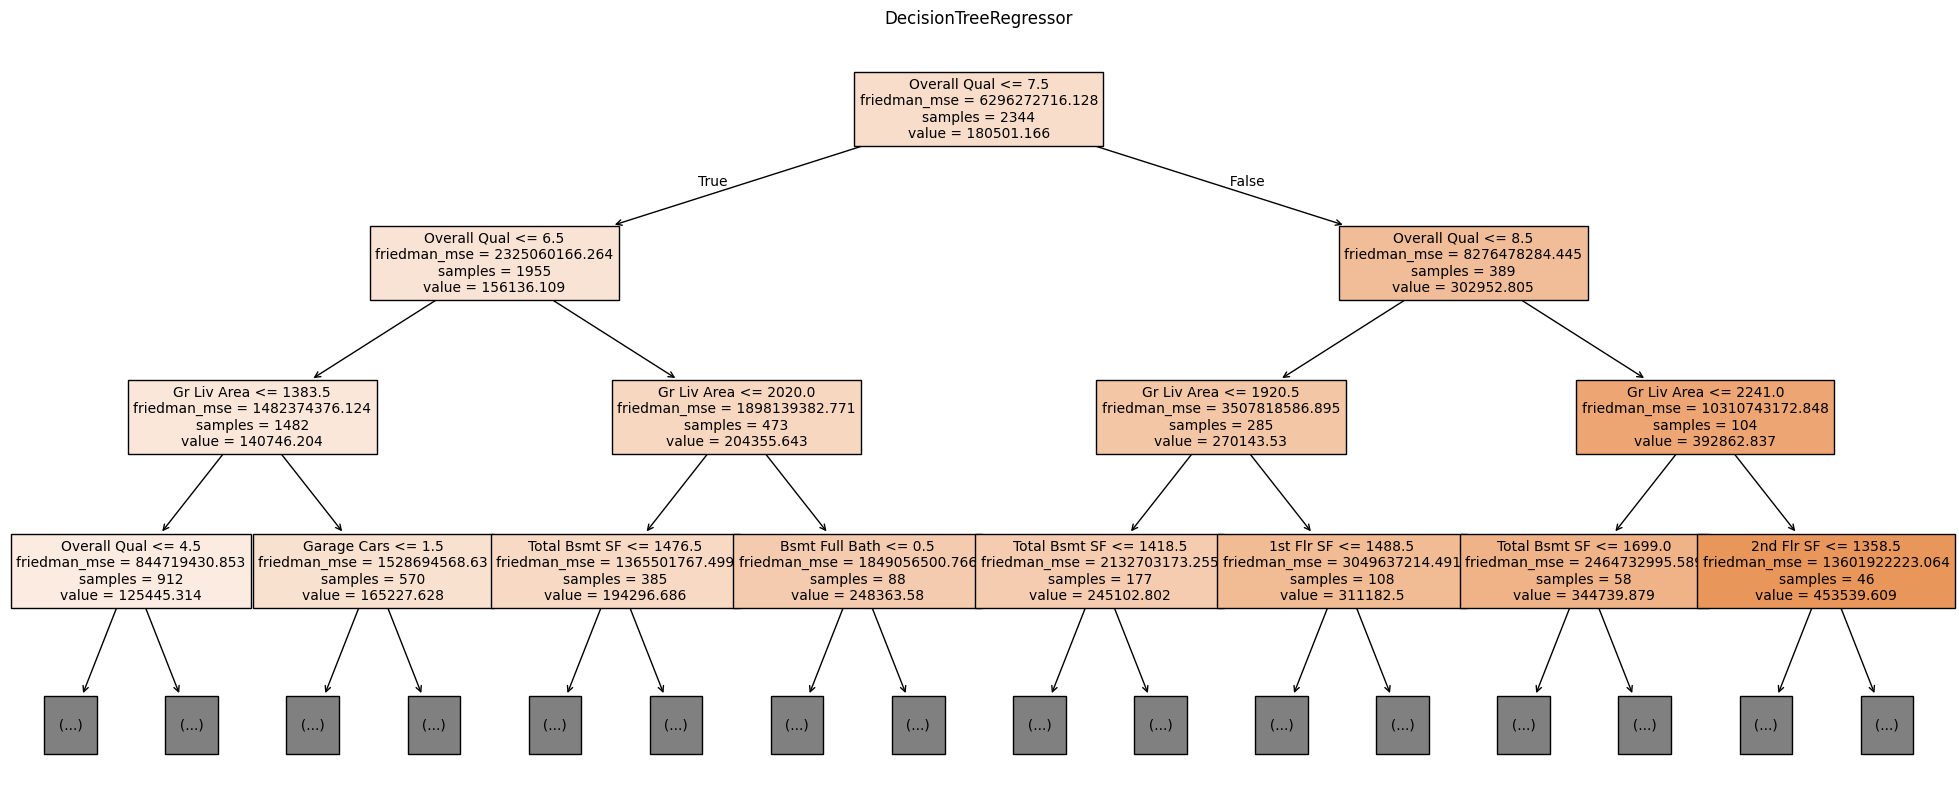

In [303]:
plt.figure(figsize=(25, 10))
plot_tree(
    fitted_tree,
    feature_names=fitted_preprocessor.get_feature_names_out(),
    filled=True,
    fontsize=10,
    max_depth=3,
)
plt.title("DecisionTreeRegressor")
plt.show()

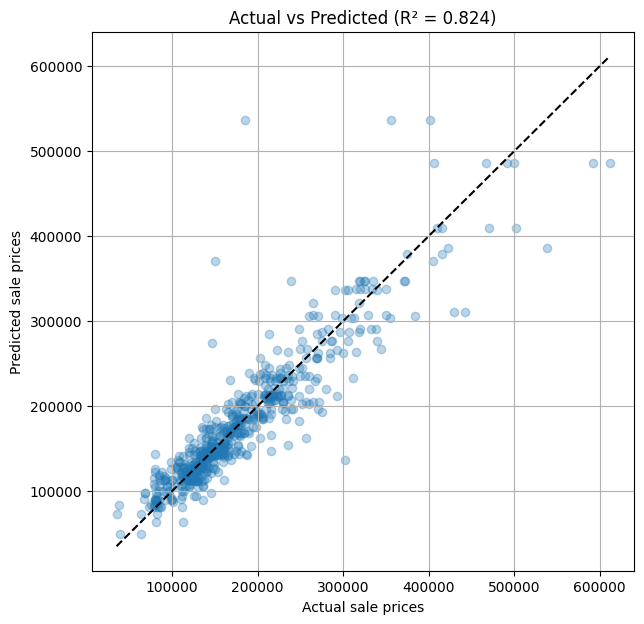

In [304]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="black",
)
plt.xlabel("Actual sale prices")
plt.ylabel("Predicted sale prices")
plt.title(f"Actual vs Predicted (R² = {r2:.3f})")
plt.grid(True)
plt.show()

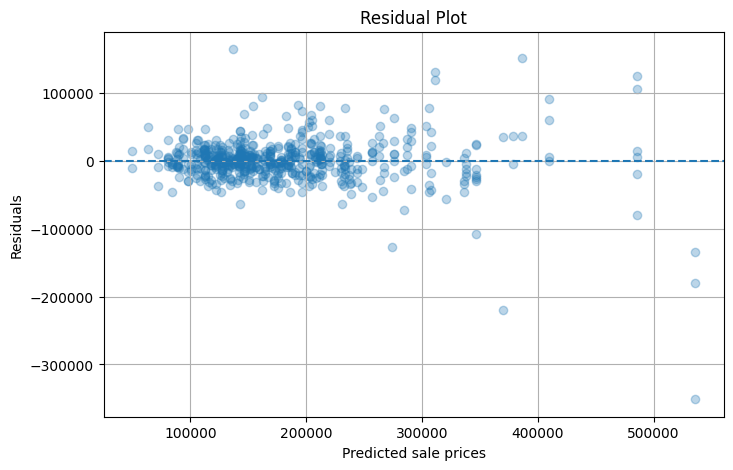

In [305]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted sale prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

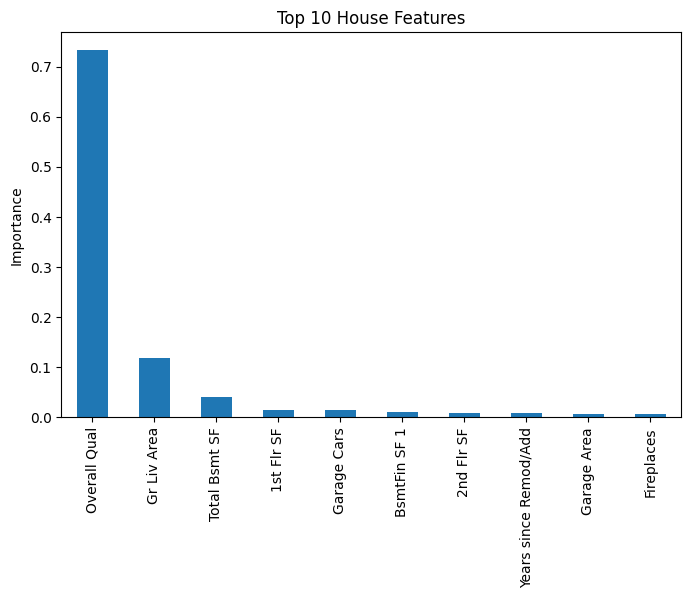

In [306]:
importances = pd.Series(
    fitted_tree.feature_importances_, index=fitted_preprocessor.get_feature_names_out()
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(10).plot(kind="bar")
plt.ylabel("Importance")
plt.title("Top 10 House Features")
plt.show()

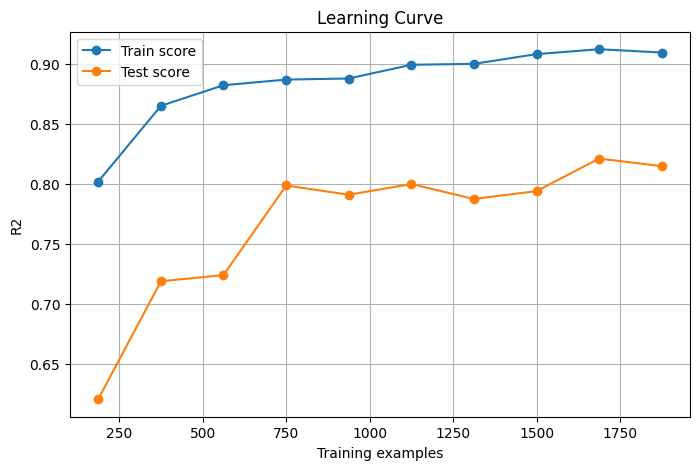

In [310]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Train score")
plt.plot(train_sizes, val_mean, marker="o", label="Test score")
plt.xlabel("Training examples")
plt.ylabel("R2")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()